This notebook provides a complete, step-by-step understanding of Decision Trees in Machine Learning using the Titanic dataset.

The goal is not only to build a model, but also to understand how decision trees actually work mathematically and intuitively.

We will explore:

How trees make decisions
How impurity is measured using Entropy and Gini
How splits are selected using Information Gain
How model complexity affects performance
How to detect and fix overfitting using pruning

By the end of this notebook, you will have both theoretical clarity and practical implementation skills.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# https://www.kaggle.com/datasets/yasserh/titanic-dataset
df = pd.read_csv(r"F:\CodeCave\Machine Learning\Datasets\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# counts missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [6]:
# replace missing categorical value with most frequent
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
df.drop('Cabin',axis=1,inplace=True)

In [8]:
# remove unnecessary columns
# axis=0 -> drop rows and axis=1 -> drop column
df.drop(['Name','Ticket','PassengerId'],axis=1,inplace=True)

In [9]:
# convert text to numbers
df = pd.get_dummies(df,drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [10]:
X = df.drop('Survived',axis=1)
y = df['Survived']

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In a Decision Tree, the main goal is to split the data in a way that makes the groups as pure as possible.

A pure node contains data points from only one class , 
A mixed node contains multiple classes

so we use Entropy and Gini index

Difference Between Entropy and gini index ->
Speed - entropy is slower but gini is faster  ,
and gini is default in sklearn  ,
entropy is more theorotical ,
gini is computationally efficient


-------------------------------------------------------------------------------------------------------------------------------------------------

Entropy measures the uncertainty or randomness in the data.

Entropy = 0 -> completely pure , 
Entropy = 1 -> highly mixed 


In [12]:
from math import log2

def entropy(y):
    # counts class labels 0 or 1
    # y = [1,1,0,0,1] => values = [0.1] and counts = [2,3]
    values , counts = np.unique(y,return_counts=True)

    # convert counts into probability
    # total = 5 so p(0) = 2/5 and p(1) = 3/5
    prob = counts/len(y)

    # entropy formula - measure impurity , 0 - pure , 1-mixed
    # output range - (0 to 1)
    return -np.sum(prob*np.log2(prob))

Gini Index measures the probability of incorrect classification.

Gini = 0 → completely pure
Higher value → more impurity



In [13]:
def gini(y):
    # counts class labels 0 and 1 
    
    values,counts = np.unique(y,return_counts=True)

    # find probability class wise
    prob = counts/len(y)

    # its alternative impurity measure and its faster than entropy 
    # output range - (0 to 0.5)
    return 1 - np.sum(prob**2)


The decision tree selects the split that gives the maximum information gain, meaning the greatest reduction in impurity.
Information gain compares the impurity  before and after spiltting , 
and the goal is to make the child nodes more pure as possible


In [14]:
# here we will measure how much impurity is reduced after the split
def information_gain(parent,left,right):
    # number of samples in left / total number of samples
    weight_left = len(left)/len(parent)
    # number of samples in right /  total number of samples
    weight_right = len(right)/len(parent)


    #entropy(parent) - this calculates how mixed is the data before spilt 
     # entropy(left) , entropy(right) - this will calculate 
     # how mixed are the new groups after split

    return entropy(parent) - (
        # here we are multiplying because bigger group should influence more
        weight_left*entropy(left)+
        weight_right*entropy(right)
    )
    # so here final substraction happens - which gives how much impurity we removed
    # high value - good split , and zero means no improvement

In [15]:
from sklearn.tree import DecisionTreeClassifier

# it creates decision tree -> train it using entropy -> limit its depth -> and learn patterns
model_entropy= DecisionTreeClassifier(
    criterion='entropy',
    max_depth=9
)
model_entropy.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [16]:
model_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=9
)

model_gini.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Initially, the model was trained using a maximum depth of 5.

Entropy Train Accuracy: 84.69% , 
Entropy Test Accuracy: 80.44% , 
Gini Train Accuracy: 84.97% , 
Gini Test Accuracy: 79.88%

But after Analysis and training model with different depths and analyzing accuracy i get to know the best depth is 9 so i used this depth 
and i got below result

Entropy Train Accuracy: 89.88% ,
Entropy Test Accuracy: 82.68% ,
Gini Train Accuracy: 90.73% ,
Gini Test Accuracy: 78.77% 

so here the accuracies increase , by using gini the model is getting test accuracy low , so its overfitting
but for entropy we are getting better performance 


In [17]:
print("Entropy Train:",model_entropy.score(X_train,y_train))
print("Entropy test:",model_entropy.score(X_test,y_test))

print("Gini Train:", model_gini.score(X_train, y_train))
print("Gini Test:", model_gini.score(X_test, y_test))

Entropy Train: 0.898876404494382
Entropy test: 0.8268156424581006
Gini Train: 0.9073033707865169
Gini Test: 0.7877094972067039


In [18]:
from sklearn.metrics import confusion_matrix

y_pred = model_entropy.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[96  9]
 [22 52]]


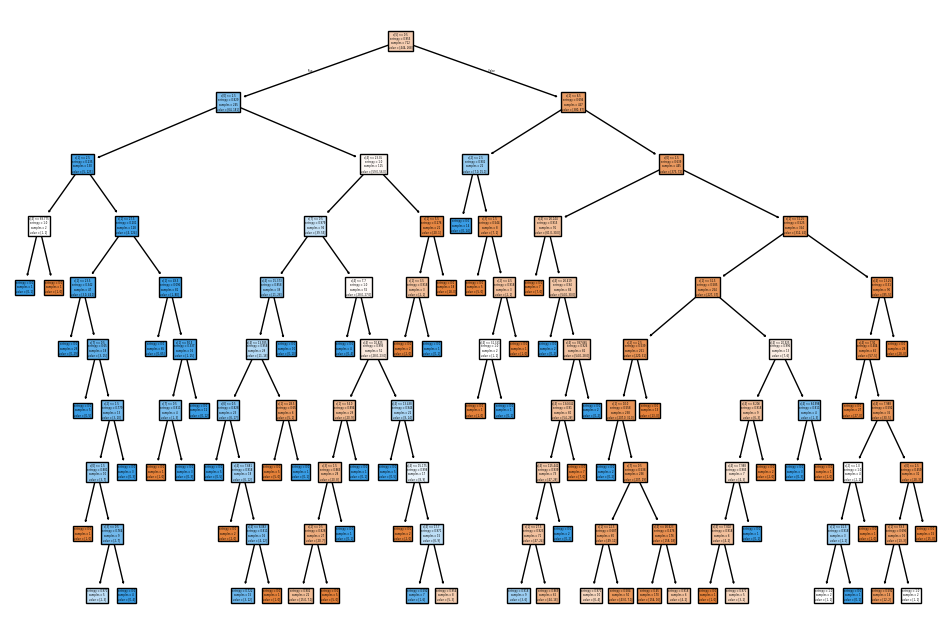

In [19]:
from sklearn import tree

plt.figure(figsize=(12,8))
tree.plot_tree(model_entropy, filled=True)
plt.show()

Here we will analyze how changing the maximum depth affects model performance on both training and testing data.

and The best model is not the one with highest training accuracy, but the one with the best test accuracy.

In [ ]:
train_scores = []
test_scores = []

# here we will train model with multiple depths (from 1 to 14)
depths = range(1, 15)

for d in depths:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=d
    )
    
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

so in graph you can see the train accuracy increases with depth ,
and test accuracy increases till depth around 8-9 ,
so module improves intially and then stop improving and start overfitting

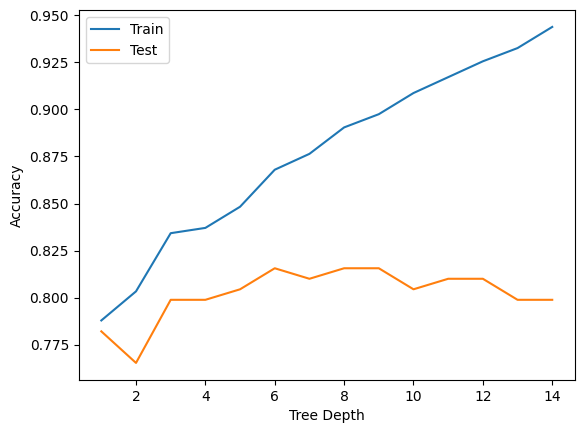

In [26]:
plt.plot(depths, train_scores, label="Train")
plt.plot(depths, test_scores, label="Test")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [27]:
# building pruned decision tree that avoids overfitting
model_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=9,
    # model will spilt only if it has atleast 20 samples
    # small groups - unreliable pattern - avoid spiltting
    min_samples_split=20,
    # after spiltting each node must have atleast 10 samples
    # tiny leaf nodes overfitting
    min_samples_leaf=10
)

model_pruned.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [28]:
print("Pruned Train:", model_pruned.score(X_train, y_train))
print("Pruned Test:", model_pruned.score(X_test, y_test))

Pruned Train: 0.8455056179775281
Pruned Test: 0.7988826815642458


In [29]:
from sklearn.metrics import classification_report

y_pred = model_pruned.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



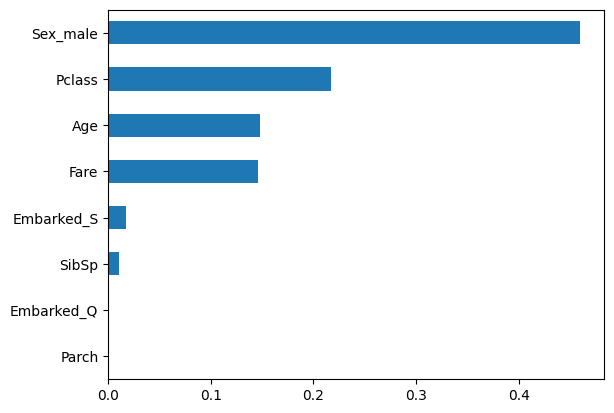

In [30]:
import pandas as pd

importance = pd.Series(model_pruned.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.show()